*Step 1 : Data loading*

In [ ]:
import pandas as pd
df=pd.read_csv("C:/Users/louis/Downloads/archive (23)/used_cars_data.csv")
df.head()

C:\Users\louis\AppData\Local\Temp\ipykernel_62016\134807965.py:1: DtypeWarning: Columns (0: dealer_zip) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("C:/Users/louis/Downloads/archive (23)/used_cars_data.csv")


,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,...,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
0,ZACNJABB5KPJ92081,35.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,Bayamon,NaN,NaN,...,A,9-Speed Automatic Overdrive,t83804,Latitude FWD,NaN,FWD,Front-Wheel Drive,101.2 in,79.6 in,2019
1,SALCJ2FX1LH858117,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
2,JF1VA2M67G9829723,35.4 in,NaN,NaN,NaN,Sedan,NaN,Guaynabo,17.0,NaN,...,M,6-Speed Manual,t58994,Base,NaN,AWD,All-Wheel Drive,104.3 in,78.9 in,2016
3,SALRR2RV0L2433391,37.6 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,NaN,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020


*Step 2 : Time Series Construction*

In [66]:
df["listed_date"] = pd.to_datetime(df["listed_date"])
df = df.sort_values("listed_date")
serie_temporelle = df.groupby("listed_date").size().to_numpy()
x = serie_temporelle[:-1]  
y = serie_temporelle[1:]    

*Step 3 : MSE Gradient Calculation*

In [67]:
def gradient_mse(a, b):
    sum_residuals = 0
    sum_x_residuals = 0

    for i in range(len(x)):
        residual = a * x[i] + b - y[i]
        sum_residuals += residual
        sum_x_residuals += x[i] * residual

    gradient_a = (1/len(x)) * sum_x_residuals
    gradient_b = (1/len(x)) * sum_residuals

    return gradient_a, gradient_b

*Step 4 : Gradient Descent Implementation*

In [68]:
import math

def descent_gradient(gradient_function,a0,b0,alpha,nb_max_iter, eps):

    a, b = a0, b0

    for i in range(1, nb_max_iter + 1):
        gradient_a, gradient_b = gradient_function(a, b)
        
        if math.hypot(gradient_a,gradient_b) < eps:
            return a, b, i

        a -= alpha * gradient_a
        b -= alpha * gradient_b

    return a, b, nb_max_iter 

*Step 5 : Application of Gradient Descent to the MSE*

In [69]:
a,b,nb_max_iter=descent_gradient(gradient_mse, a0=0.0, b0=0.0, alpha=1e-8, nb_max_iter=10000, eps=1e-6)
print(a,b,nb_max_iter)

0.9301642845007433 0.012019640831101241 10000


*Step 6 : AR(1) Model Prediction*

In [70]:
def model(x):
    return a * x + b

prediction = model(x)

*Step 7 : AR(1) Model Visualization*

Text(0.5, 1.0, 'AR(1) : relation entre deux jours consécutifs')

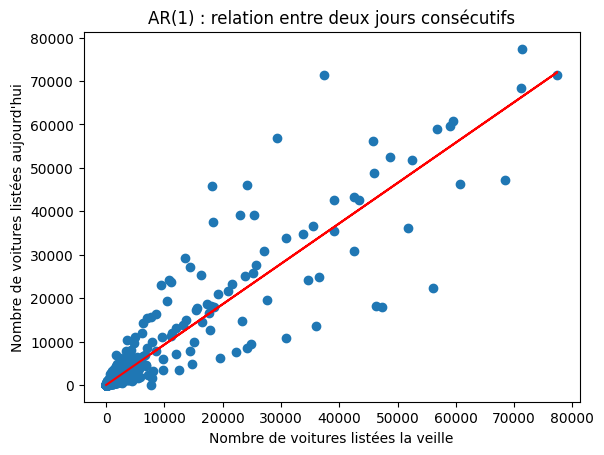

In [72]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.plot(x, prediction, c="r")
plt.xlabel("Nombre de voitures listées la veille")
plt.ylabel("Nombre de voitures listées aujourd'hui")
plt.title("AR(1) : relation entre deux jours consécutifs")